<a href="https://colab.research.google.com/github/OJB-Quantum/Hi-Res-Image-to-SVG/blob/main/Hi_Res_Image_to_SVG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install --system opencv-python-headless cupy-cuda12x matplotlib

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 143ms


Please upload your target high-resolution raster image:
Supported formats: .png, .jpeg, .jpg, .bmp, .tif, .tiff


Saving Screenshot 2026-03-30 180233.png to Screenshot 2026-03-30 180233.png

Decoding image matrix for: Screenshot 2026-03-30 180233.png
Transferring 3764920 pixels to GPU for 8-bit quantization...

--- Processing Complete ---


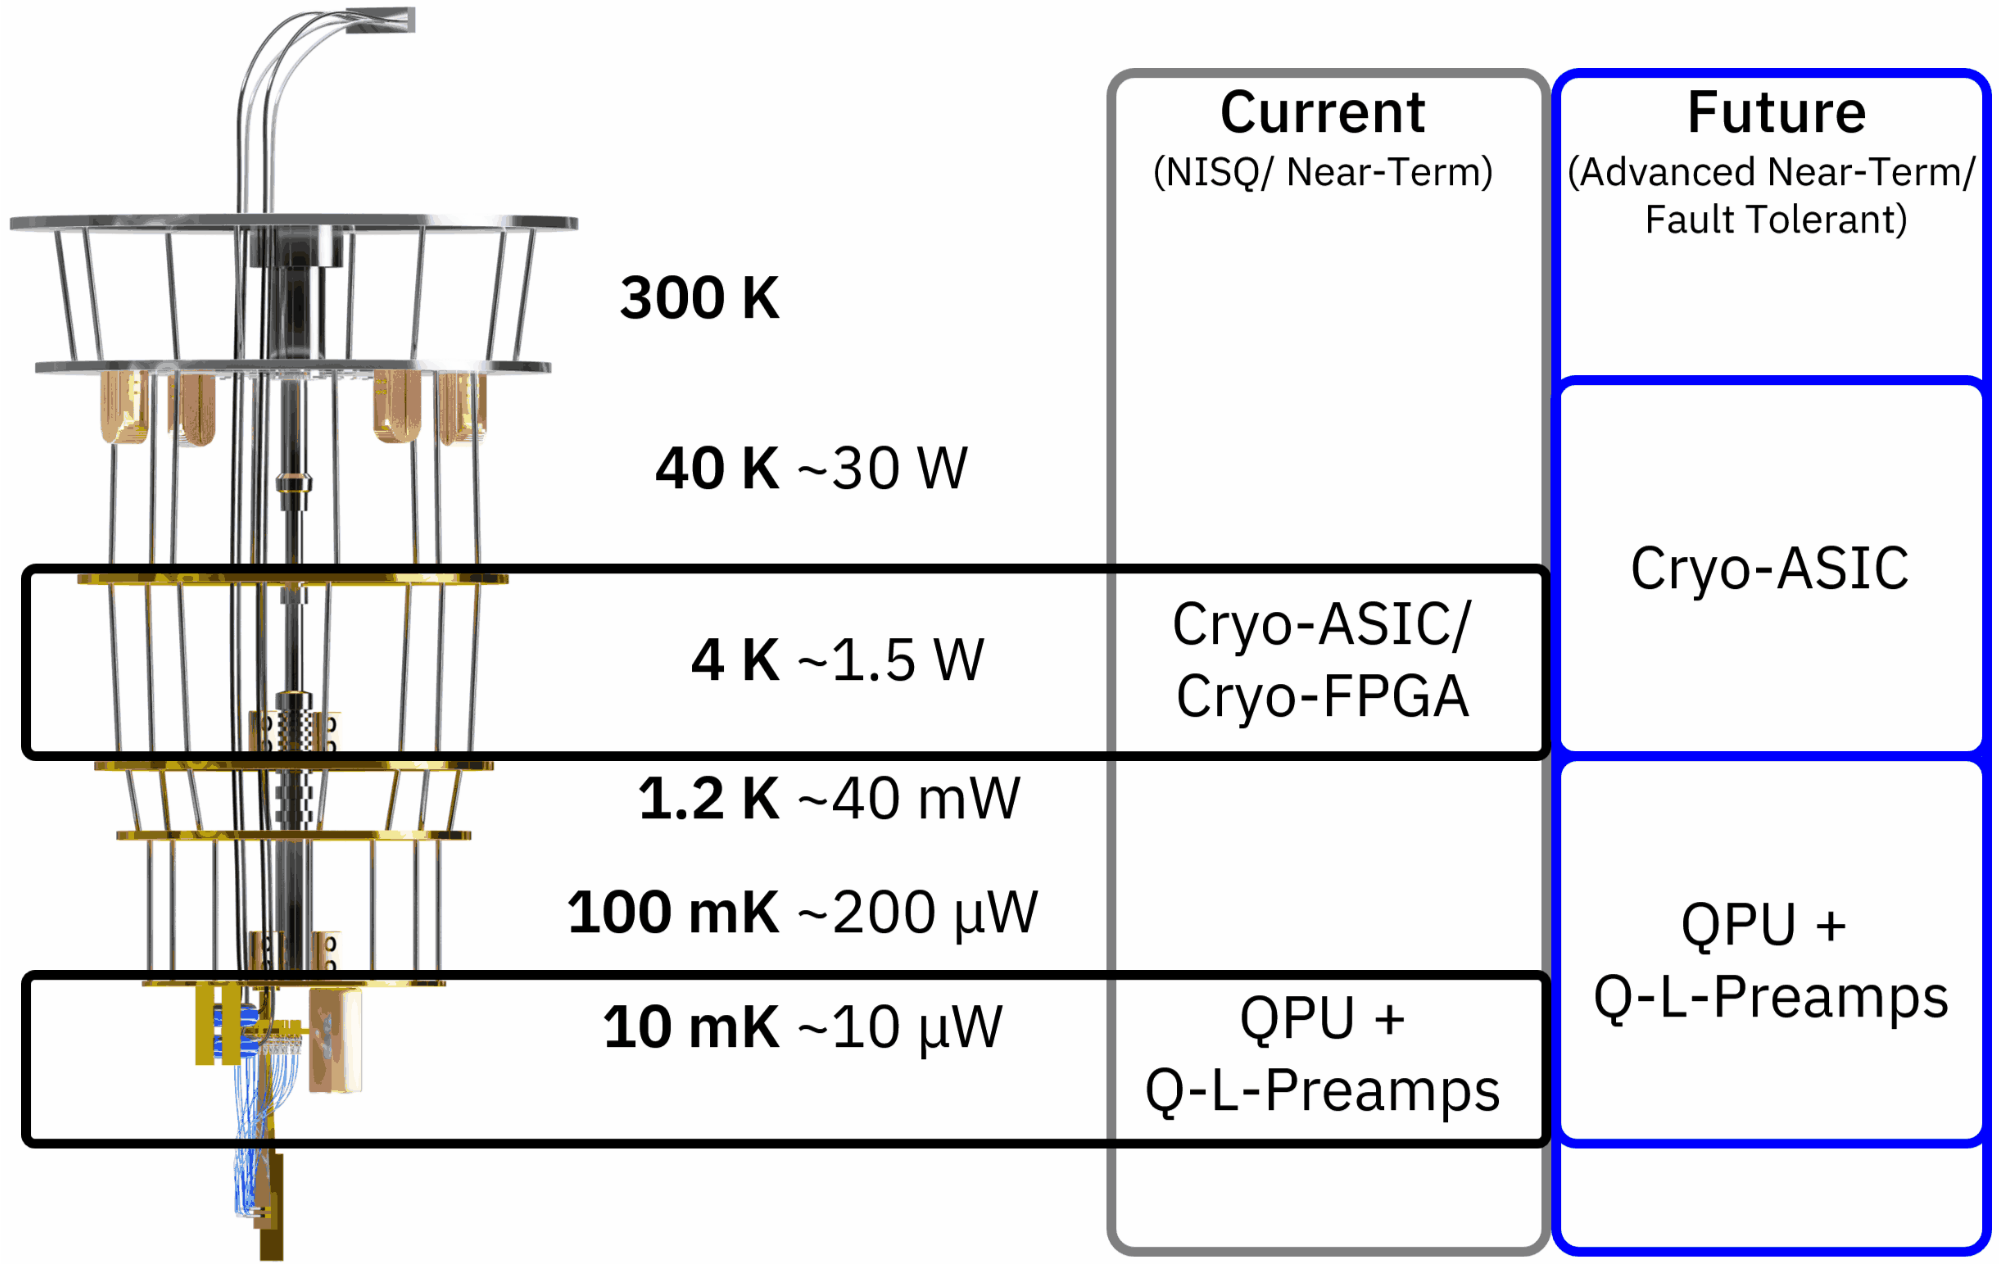

In [2]:
"""
Process high-resolution images via GPU color quantization and SVG embedding.

This module prompts the user to upload a raster image (PNG, JPEG, BMP, TIFF),
utilizes CuPy to perform K-Means clustering for 8-bit color reduction, and
wraps the resultant optimized raster data into a downloadable SVG file.
"""

import base64
import io
import os
from typing import Tuple

import cv2
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from IPython.display import HTML, SVG, display


# =====================================================================
# CONTROL KNOBS: Parameterize your extraction and rendering here.
# =====================================================================
TARGET_WIDTH_PX = 2000           # Output width of the generated SVG.
SCAN_RESOLUTION_DPI = 1000       # Target physical scanning resolution.
COLOR_ACCURACY_BITS = 8          # Color depth (8 bits = 256 colors).
KMEANS_ITERATIONS = 15           # Cycles for cluster stabilization.
# =====================================================================

# Global plotting defaults per styling constraints
plt.rcParams['figure.dpi'] = 250


def quantize_colors_gpu(img_array: np.ndarray, bits: int) -> np.ndarray:
    """
    Reduce image color space using GPU-accelerated K-Means clustering.

    Args:
        img_array: The input image as an RGB NumPy array.
        bits: The target color bit-depth.

    Returns:
        A quantized NumPy array containing the color-reduced image.
    """
    num_colors = 2 ** bits
    h, w, c = img_array.shape

    print(f"Transferring {h * w} pixels to GPU for {bits}-bit quantization...")

    # Reshape image to a 2D array of pixels and transfer to GPU memory
    pixels_gpu = cp.asarray(img_array, dtype=cp.float32).reshape(-1, 3)
    num_pixels = pixels_gpu.shape[0]

    # Initialize centroids by randomly sampling existing pixel colors
    random_indices = cp.random.choice(num_pixels, num_colors, replace=False)
    centroids = pixels_gpu[random_indices]

    distances = cp.zeros((num_pixels, num_colors), dtype=cp.float32)

    for iteration in range(KMEANS_ITERATIONS):
        # Calculate Euclidean distances from all pixels to all centroids
        for i in range(num_colors):
            distances[:, i] = cp.sum((pixels_gpu - centroids[i]) ** 2, axis=1)

        # Assign each pixel to the nearest centroid
        labels = cp.argmin(distances, axis=1)

        # Update centroids to the mean of their assigned pixels
        for i in range(num_colors):
            mask = (labels == i)
            if cp.any(mask):
                centroids[i] = cp.mean(pixels_gpu[mask], axis=0)

    # Map the clustered centroids back to the pixel array
    quantized_pixels = centroids[labels].astype(cp.uint8)
    quantized_img = quantized_pixels.reshape(h, w, 3)

    # Transfer matrix back to CPU RAM
    return cp.asnumpy(quantized_img)


def scale_image_dimensions(
    orig_w: int,
    orig_h: int,
    target_w: int
) -> Tuple[int, int]:
    """
    Calculate proportional height based on the targeted constant width.

    Args:
        orig_w: Original image width in pixels.
        orig_h: Original image height in pixels.
        target_w: Desired image width in pixels.

    Returns:
        A tuple containing (scaled_width, scaled_height).
    """
    aspect_ratio = orig_h / orig_w
    target_h = int(target_w * aspect_ratio)
    return target_w, target_h


def generate_svg_from_array(
    img_array: np.ndarray,
    filename: str
) -> None:
    """
    Embed a processed NumPy array into an SVG and serve a download link.

    Args:
        img_array: The RGB image array to embed.
        filename: The original filename to derive the output name from.
    """
    # Convert RGB back to BGR for OpenCV encoding
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

    # Serialize image to PNG byte stream
    success, buffer = cv2.imencode('.png', img_bgr)
    if not success:
        print("Failed to encode the processed image matrix.")
        return

    b64_encoded = base64.b64encode(buffer).decode('utf-8')
    image_uri = f"data:image/png;base64,{b64_encoded}"

    orig_h, orig_w = img_array.shape[:2]
    scaled_w, scaled_h = scale_image_dimensions(
        orig_w, orig_h, TARGET_WIDTH_PX
    )

    # Construct the SVG Document Object Model
    # Physical dimensions can be inferred by viewing agents using the DPI
    svg_content = f"""<svg xmlns="http://www.w3.org/2000/svg"
         width="{scaled_w}" height="{scaled_h}"
         viewBox="0 0 {orig_w} {orig_h}"
         data-resolution="{SCAN_RESOLUTION_DPI}dpi">
        <image href="{image_uri}" x="0" y="0"
               width="{orig_w}" height="{orig_h}" />
    </svg>"""

    base_name = os.path.splitext(filename)[0]
    out_filename = f"{base_name}_8bit_vectorized.svg"

    svg_b64 = base64.b64encode(svg_content.encode('utf-8')).decode('utf-8')
    svg_uri = f"data:image/svg+xml;base64,{svg_b64}"

    html_button = f"""
    <a href="{svg_uri}" download="{out_filename}"
       style="display: inline-block; padding: 10px 20px; margin: 15px 0px;
              background-color: #6f42c1; color: white; text-decoration: none;
              border-radius: 5px; font-family: monospace; font-size: 14px;
              font-weight: bold;">
       💾 Download {out_filename}
    </a>
    <br>
    """

    print("\n--- Processing Complete ---")
    display(HTML(html_button))
    display(SVG(svg_content))


def main() -> None:
    """
    Execute the interactive GPU image processing pipeline.
    """
    print("Please upload your target high-resolution raster image:")
    print("Supported formats: .png, .jpeg, .jpg, .bmp, .tif, .tiff")
    uploaded_files = files.upload()

    if not uploaded_files:
        print("No file was uploaded. Terminating process.")
        return

    for file_name, file_data in uploaded_files.items():
        print(f"\nDecoding image matrix for: {file_name}")

        # Decode the byte stream directly into an OpenCV matrix
        img_array_bgr = cv2.imdecode(
            np.frombuffer(file_data, np.uint8),
            cv2.IMREAD_COLOR
        )

        if img_array_bgr is None:
            print(f"Error: Unable to decode {file_name}. Ensure format is valid.")
            continue

        # Standardize matrix to RGB color space
        img_array_rgb = cv2.cvtColor(img_array_bgr, cv2.COLOR_BGR2RGB)

        # Apply GPU-accelerated K-Means color quantization
        quantized_img = quantize_colors_gpu(img_array_rgb, COLOR_ACCURACY_BITS)

        # Package and serve the final SVG file
        generate_svg_from_array(quantized_img, file_name)


if __name__ == "__main__":
    main()